In [2]:
base_path = r'data/smartphone_addiction'
train_path = base_path + '/' + 'train.csv'
test_path = base_path + '/' + 'test.csv'

In [3]:
import os
os.path.exists('../../' + base_path)

True

In [4]:
os.listdir()

['initial.ipynb',
 'mlflow.db',
 'mlruns',
 'sample_submission.csv',
 'submission005.csv',
 'submission006.csv',
 'submission007.csv',
 'test.csv',
 'trail_1_enseble.ipynb',
 'train.csv']

In [5]:
train_df = pd.read_csv('../../'+ train_path)

In [6]:
df = train_df.copy()

In [7]:
df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [8]:
df.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [9]:
# Column names and types
TARGET = "addicted_label"
ID = "id"
num_cols = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
]

cat_cols = [
    'gender',               # Male, Female, Other  
    'stress_level',         # High, Low, Medium
    'academic_work_impact'  # Yes, No
]

#### A Solution from DeepSeek

In [10]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

import xgboost as xgb

# for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [11]:
# df = pd.read_csv('your_dataset.csv')
# For demonstration, we assume df is already defined.
# Let's check its shape and columns.
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nTarget distribution:\n", df['addicted_label'].value_counts())

Shape: (691369, 14)

Columns:
 ['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'addicted_label']

Target distribution:
 addicted_label
1    490474
0    200895
Name: count, dtype: int64


In [12]:
X = df.drop(columns=['id', 'addicted_label'])
y = df['addicted_label']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target balance:\n", y.value_counts(normalize=True))

Features shape: (691369, 12)
Target shape: (691369,)
Target balance:
 addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64


In [13]:
# Identify columns by type
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# Preprocessing for numerical: impute with median then scale
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical: impute with most frequent then one-hot encode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

Numerical columns: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
Categorical columns: ['gender', 'stress_level', 'academic_work_impact']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print("Train target distribution:\n", y_train.value_counts(normalize=True))

Train size: 553095, Test size: 138274
Train target distribution:
 addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64


In [15]:
# Logistic Regression pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',   # handles imbalance
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

# Fit the model
lr_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("===== Logistic Regression =====")
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_lr)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_lr)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_lr)))
print("F1-score: {:.4f}".format(f1_score(y_test, y_pred_lr)))
print("ROC-AUC: {:.4f}".format(roc_auc_score(y_test, y_proba_lr)))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

===== Logistic Regression =====
Accuracy: 0.8331
Precision: 0.9284
Recall: 0.8287
F1-score: 0.8757
ROC-AUC: 0.9108

Confusion Matrix:
 [[33906  6273]
 [16804 81291]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.84      0.75     40179
           1       0.93      0.83      0.88     98095

    accuracy                           0.83    138274
   macro avg       0.80      0.84      0.81    138274
weighted avg       0.85      0.83      0.84    138274



In [19]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
# XGBoost pipeline

In [22]:
# Compute scale_pos_weight = (number of negative samples) / (number of positive samples)
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.4f}")

# XGBoost pipeline (still uses the same preprocessor)
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=5000,
        learning_rate=0.025,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# Fit the model (with early stopping, but we need to pass validation set)
# We'll extract the preprocessed data and train XGBoost directly for early stopping.
# Since we have a pipeline, we can fit normally, but early stopping requires a validation set.
# Alternative: transform the training data first, then fit XGBoost with eval_set.

# Option 1: Use pipeline without early stopping (still fine)
xgb_pipeline.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("\n===== XGBoost =====")
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_xgb)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_xgb)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_xgb)))
print("F1-score: {:.4f}".format(f1_score(y_test, y_pred_xgb)))
print("ROC-AUC: {:.4f}".format(roc_auc_score(y_test, y_proba_xgb)))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

scale_pos_weight = 0.4096

===== XGBoost =====
Accuracy: 0.8878
Precision: 0.9595
Recall: 0.8789
F1-score: 0.9174
ROC-AUC: 0.9626

Confusion Matrix:
 [[36539  3640]
 [11879 86216]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.91      0.82     40179
           1       0.96      0.88      0.92     98095

    accuracy                           0.89    138274
   macro avg       0.86      0.89      0.87    138274
weighted avg       0.90      0.89      0.89    138274



In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency

# Load your data
# train_df = pd.read_csv(r'train.csv')  # Adjust path
test_df = pd.read_csv(r'test.csv')    # Adjust path

# Drop 'id' as it's irrelevant for distribution checks (it's just an index)
train_df = train_df.drop(columns=['id'], errors='ignore')
test_df = test_df.drop(columns=['id'], errors='ignore')

# Separate target from train for analysis (we only compare features)
y_train = train_df['addicted_label'] if 'addicted_label' in train_df else None
X_train = train_df.drop(columns=['addicted_label'], errors='ignore')
X_test = test_df  # Test has no target

print(f"Train features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print("\nTrain Columns:", X_train.columns.tolist())
print("Test Columns:", X_test.columns.tolist())

# Ensure columns match exactly (in case of typos)
assert (X_train.columns == X_test.columns).all(), "Columns do not match between train and test!"

Train features shape: (691369, 12)
Test features shape: (296302, 12)

Train Columns: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']
Test Columns: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']


Missing Value Comparison:
                          Train_Missing_%  Test_Missing_%
social_media_hours             19.381112       15.996180
gaming_hours                   18.343461       20.053864
weekend_screen_time            16.208855       17.109908
daily_screen_time_hours        13.864376       11.065737
app_opens_per_day              11.673940        8.675271
notifications_per_day           9.775388       11.549365
stress_level                    7.976638        6.623647
work_study_hours                7.451592        9.374557
sleep_hours                     6.433612        7.578417
academic_work_impact            6.396584        8.680670
gender                          4.199494        4.796458
age                             4.184307        5.783964


<Figure size 1200x600 with 0 Axes>

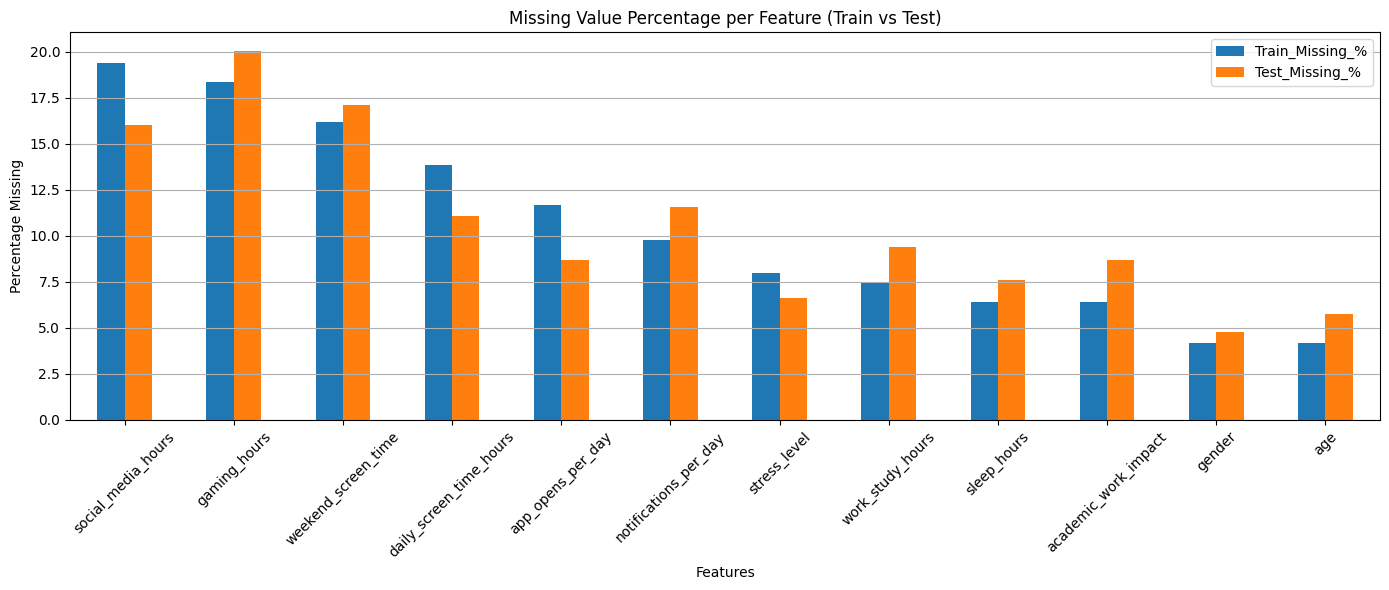

In [24]:
missing_train = X_train.isnull().mean() * 100
missing_test = X_test.isnull().mean() * 100

missing_df = pd.DataFrame({
    'Train_Missing_%': missing_train,
    'Test_Missing_%': missing_test
}).sort_values(by='Train_Missing_%', ascending=False)

print("Missing Value Comparison:\n", missing_df)

# Visualization
plt.figure(figsize=(12, 6))
missing_df.plot(kind='bar', figsize=(14, 6))
plt.title('Missing Value Percentage per Feature (Train vs Test)')
plt.ylabel('Percentage Missing')
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [25]:
# Identify numeric and categorical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", num_cols)
print("Categorical features:", cat_cols)

# Combine statistics
train_stats = X_train[num_cols].describe(percentiles=[.25, .5, .75])
test_stats = X_test[num_cols].describe(percentiles=[.25, .5, .75])

# Concatenate side-by-side for easy comparison (mean, std, min, max)
compare_df = pd.concat([
    train_stats.loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].add_prefix('Train_'),
    test_stats.loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].add_prefix('Test_')
], axis=1)

print("\n=== Numerical Feature Statistics Comparison ===\n")
print(compare_df.round(2))

Numerical features: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
Categorical features: ['gender', 'stress_level', 'academic_work_impact']

=== Numerical Feature Statistics Comparison ===

      Train_age  Train_daily_screen_time_hours  Train_social_media_hours  \
mean      26.62                           7.64                      2.47   
std        5.15                           2.72                      1.32   
min       18.00                           0.50                      0.00   
25%       22.00                           5.48                      1.45   
50%       27.00                           7.77                      2.31   
75%       31.00                           9.84                      3.37   
max       35.00                          15.00                      8.00   

      Train_gaming_hours  Train_work_study_hours  Train_sleep_hours  \


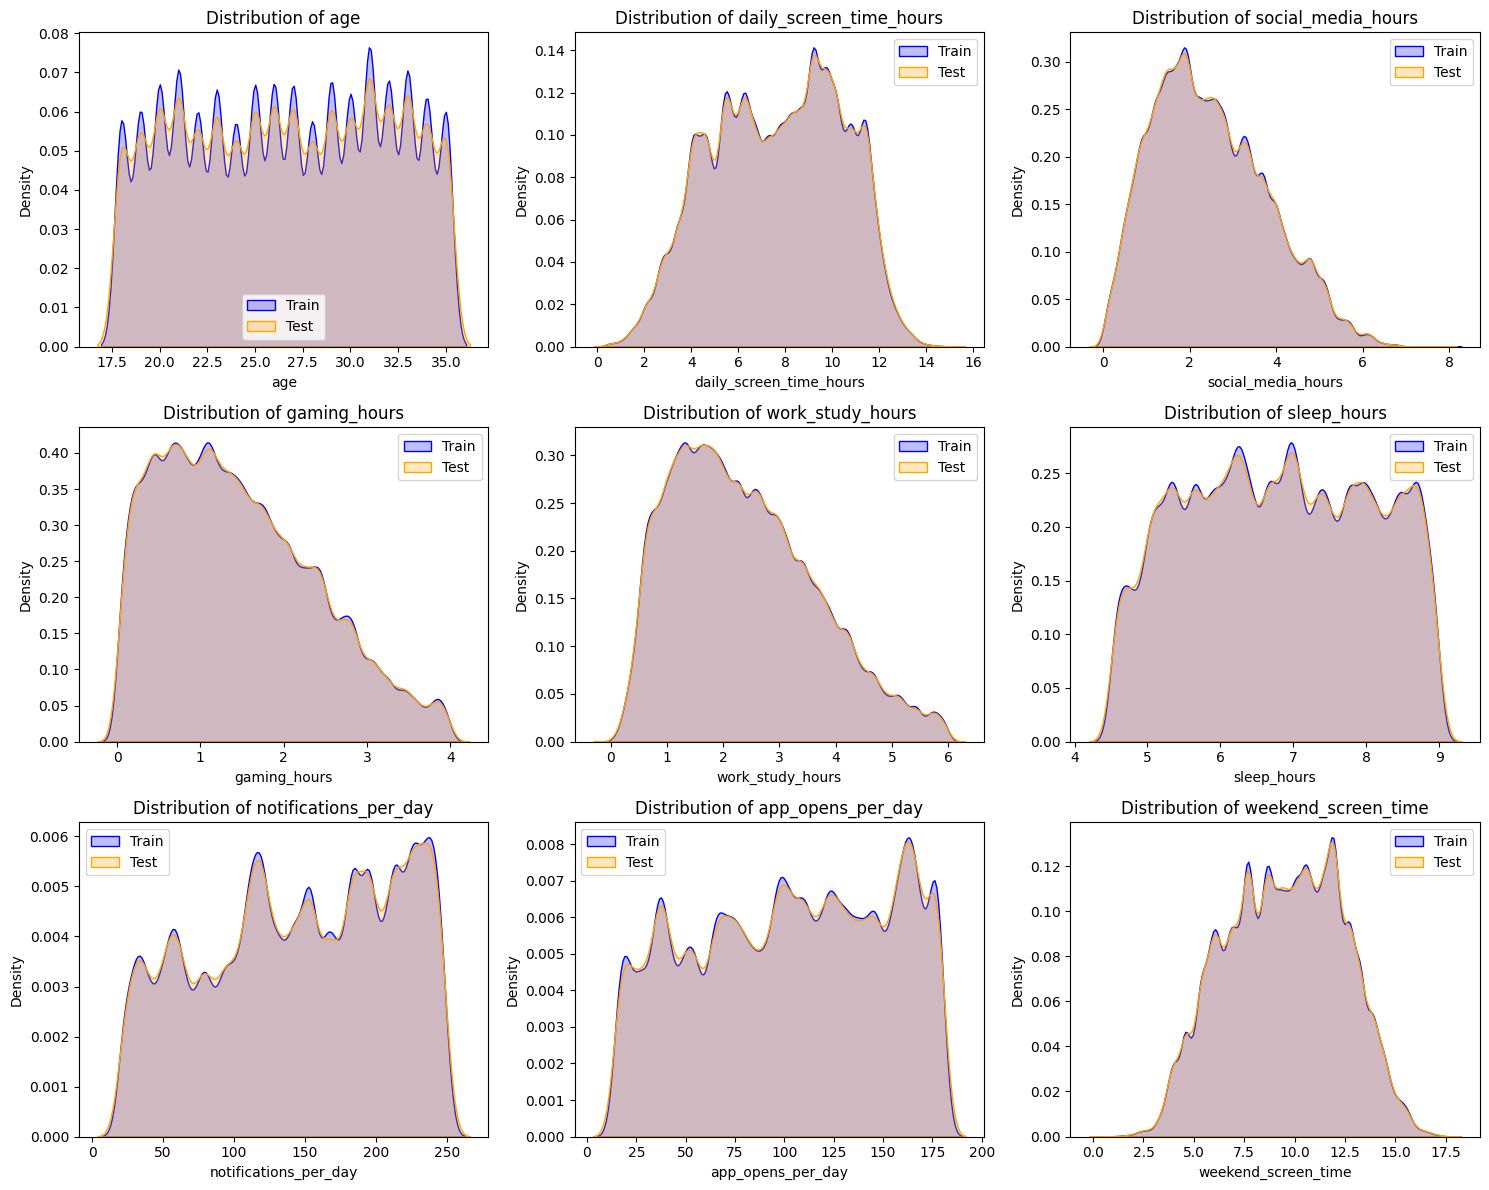

In [27]:
n_features = len(num_cols)
n_cols = 3
n_rows = (n_features // n_cols) + (n_features % n_cols > 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Drop NaNs for KDE
    train_vals = X_train[col].dropna()
    test_vals = X_test[col].dropna()
    
    sns.kdeplot(train_vals, label='Train', shade=True, ax=axes[i], color='blue')
    sns.kdeplot(test_vals, label='Test', shade=True, ax=axes[i], color='orange')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend()

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


===== gender =====
        Train_%  Test_%
gender                 
Female   0.3346  0.3343
Male     0.3377  0.3380
Other    0.3277  0.3277
✅ All test categories are present in training.


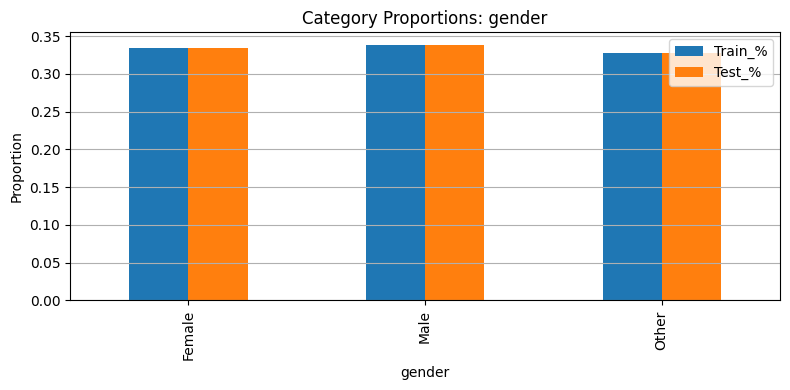


===== stress_level =====
              Train_%  Test_%
stress_level                 
High           0.3472  0.3456
Low            0.3266  0.3280
Medium         0.3262  0.3264
✅ All test categories are present in training.


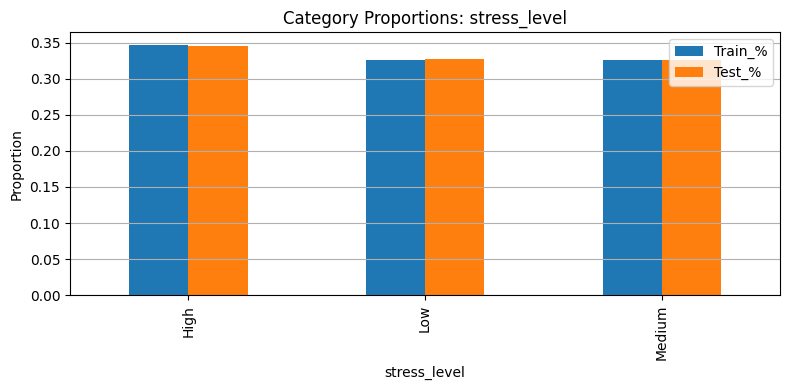


===== academic_work_impact =====
                      Train_%  Test_%
academic_work_impact                 
No                     0.4892  0.4874
Yes                    0.5108  0.5126
✅ All test categories are present in training.


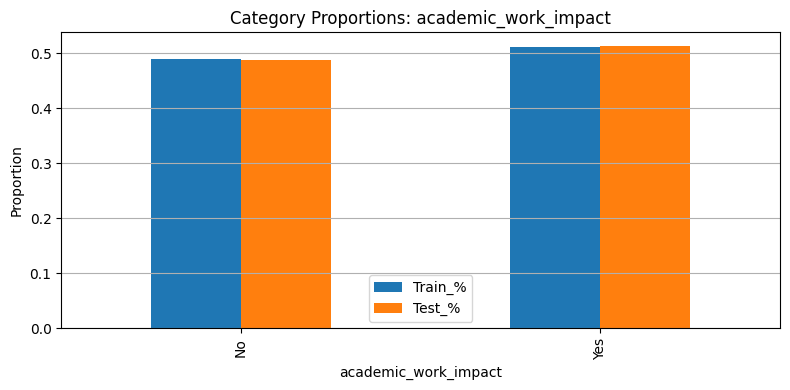

In [28]:
for col in cat_cols:
    print(f"\n===== {col} =====")
    
    train_counts = X_train[col].value_counts(normalize=True).sort_index()
    test_counts = X_test[col].value_counts(normalize=True).sort_index()
    
    # Align indexes to show both
    comp = pd.DataFrame({'Train_%': train_counts, 'Test_%': test_counts}).fillna(0)
    print(comp.round(4))
    
    # Check for unseen categories
    train_unique = set(X_train[col].dropna().unique())
    test_unique = set(X_test[col].dropna().unique())
    unseen = test_unique - train_unique
    if unseen:
        print(f"⚠️ WARNING: Test contains categories NOT in Train: {unseen}")
    else:
        print("✅ All test categories are present in training.")

    # Bar plot
    fig, ax = plt.subplots(figsize=(8, 4))
    comp.plot(kind='bar', ax=ax)
    ax.set_title(f'Category Proportions: {col}')
    ax.set_ylabel('Proportion')
    ax.grid(axis='y')
    plt.tight_layout()
    plt.show()

In [29]:
print("=== Statistical Drift Tests ===")
print("(Note: With large N, p-values are irrelevant. Look at the magnitude of the statistic.)\n")

# Numerical: KS Test
print("--- Numeric (KS Test) ---")
for col in num_cols:
    train_vals = X_train[col].dropna()
    test_vals = X_test[col].dropna()
    if len(train_vals) > 0 and len(test_vals) > 0:
        stat, p = ks_2samp(train_vals, test_vals)
        # Interpretation: D-stat > 0.1 is usually considered notable drift
        print(f"{col:25} | D-stat: {stat:.4f} | p-value: {p:.4e}")

print("\n--- Categorical (Chi-Squared) ---")
for col in cat_cols:
    # Create contingency table
    train_counts = X_train[col].value_counts()
    test_counts = X_test[col].value_counts()
    # Align indexes
    combined = pd.concat([train_counts, test_counts], axis=1, keys=['Train', 'Test']).fillna(0)
    # Chi2 test
    chi2, p, dof, expected = chi2_contingency(combined)
    print(f"{col:25} | Chi2: {chi2:.4f} | p-value: {p:.4e}")

=== Statistical Drift Tests ===
(Note: With large N, p-values are irrelevant. Look at the magnitude of the statistic.)

--- Numeric (KS Test) ---
age                       | D-stat: 0.0014 | p-value: 8.0411e-01
daily_screen_time_hours   | D-stat: 0.0017 | p-value: 6.4674e-01
social_media_hours        | D-stat: 0.0016 | p-value: 7.7026e-01
gaming_hours              | D-stat: 0.0021 | p-value: 4.5975e-01
work_study_hours          | D-stat: 0.0009 | p-value: 9.9735e-01
sleep_hours               | D-stat: 0.0022 | p-value: 3.1921e-01
notifications_per_day     | D-stat: 0.0027 | p-value: 1.4003e-01
app_opens_per_day         | D-stat: 0.0021 | p-value: 3.8943e-01
weekend_screen_time       | D-stat: 0.0017 | p-value: 7.2023e-01

--- Categorical (Chi-Squared) ---
gender                    | Chi2: 0.1248 | p-value: 9.3949e-01
stress_level              | Chi2: 2.5086 | p-value: 2.8528e-01
academic_work_impact      | Chi2: 2.3901 | p-value: 1.2211e-01


## How to Interpret These Results & Make Decisions

| What you observe | Interpretation | Decision / Action |
|---|---|---|
| **Missing % are similar** | Good. Your imputation strategy (median/frequent) applies consistently. | No action needed. |
| **Test has 10%+ more missing in a feature** | The imputed values (e.g., median) might be a poor substitute for the actual missing mechanism. | Re-train the model using a **Missing Indicator** or **Iterative Imputation (MICE)**. Alternatively, drop that feature if it becomes too unstable. |
| **Mean/Std of a numeric feature shifts > 20%** (e.g., avg screen time: 7.6 in train vs. 9.0 in test) | The model is extrapolating. Logistic regression is linear and can drastically change probabilities in unseen ranges. Tree-based models (e.g., XGBoost) also extrapolate poorly, but generally handle interpolation better. | **Do not deploy blindly.** Consider re-training the model on a weighted dataset where test-like samples are up-weighted. If possible, collect a small labeled sample from the test distribution to fine-tune the model. |
| **KDE plots show completely different shapes** (e.g., multimodal vs. unimodal) | The relationship between features and the target might have changed substantially. | Re-train using a **Domain Adaptation** technique (e.g., CORAL), or re-train with a combined dataset if labels are available. |
| **Categorical proportions shift heavily** (e.g., Train: 50% Male, Test: 20% Male) | The model learned specific coefficients for "Male." If the test set has fewer males, the overall prediction distribution may shift. | Calibrate the model's probabilities using **Isotonic Regression** or **Platt Scaling** on a labeled hold-out sample from the target domain. |
| **Unseen categories in Test** (e.g., Test has "Very High" stress, while Train only has "High/Low/Medium") | Your One-Hot Encoder will either drop the new category (if configured to ignore unknowns) or throw an error. The model won't know how to represent it. | Set `OneHotEncoder(handle_unknown='ignore')`. More importantly, group rare categories into an **"Other"** bucket during training, or consider target encoding instead of one-hot encoding. |
| **High Drift Statistic** (`D > 0.1` or very large Chi-square statistic) | Strong evidence of data drift. | **Do not use the model's predicted probabilities as-is.** Use batch recalibration and/or continuously monitor model performance with a shadow deployment. |


## Train and test feature distributions are similar
Lets proceed with building the model

In [32]:
# Preprocessing for numerical: impute with median, then scale
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical: impute with most frequent, then one-hot encode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # handle_unknown='ignore' is safe in case test has unseen categories (though we found none)
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

In [34]:
from sklearn.model_selection import cross_validate

# Build the pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

# Define scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Run 5-fold cross-validation
# n_jobs=-1 uses all CPU cores for parallel fold execution
cv_results_lr = cross_validate(
    lr_pipeline, X, y,
    cv=5,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,   # we only care about validation performance
    verbose=1                   # shows progress
)

# Display results
print("\n===== Logistic Regression - 5-Fold CV =====")
for metric in scoring:
    scores = cv_results_lr[f'test_{metric}']
    print(f"{metric.capitalize():10} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

# Show per-fold details
cv_df_lr = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_results_lr['test_accuracy'],
    'Precision': cv_results_lr['test_precision'],
    'Recall': cv_results_lr['test_recall'],
    'F1': cv_results_lr['test_f1'],
    'ROC-AUC': cv_results_lr['test_roc_auc']
})
print("\nPer-fold results:")
print(cv_df_lr.round(4))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.



===== Logistic Regression - 5-Fold CV =====
Accuracy   | Mean: 0.8339 | Std: 0.0005
Precision  | Mean: 0.9290 | Std: 0.0007
Recall     | Mean: 0.8292 | Std: 0.0011
F1         | Mean: 0.8763 | Std: 0.0004
Roc_auc    | Mean: 0.9119 | Std: 0.0003

Per-fold results:
   Fold  Accuracy  Precision  Recall      F1  ROC-AUC
0     1    0.8335     0.9302  0.8275  0.8758   0.9125
1     2    0.8341     0.9290  0.8295  0.8764   0.9117
2     3    0.8332     0.9286  0.8286  0.8757   0.9115
3     4    0.8342     0.9279  0.8308  0.8767   0.9117
4     5    0.8345     0.9293  0.8298  0.8768   0.9120


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    7.6s finished


In [37]:
from sklearn.utils.class_weight import compute_class_weight

# Compute scale_pos_weight for XGBoost
neg, pos = np.bincount(y)
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.4f}")

# Build XGBoost pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=2500,               # you can increase to 200+ later
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',             # much faster on large data
        n_jobs=1,                       # avoid nested parallelism (CV will parallelize outer loops)
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# Run CV (this may take 10-30 minutes depending on your CPU)
cv_results_xgb = cross_validate(
    xgb_pipeline, X, y,
    cv=5,
    scoring=scoring,
    n_jobs=-1,          # runs the 5 folds in parallel
    return_train_score=False,
    verbose=1
)

# Display results
print("\n===== XGBoost - 5-Fold CV =====")
for metric in scoring:
    scores = cv_results_xgb[f'test_{metric}']
    print(f"{metric.capitalize():10} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

cv_df_xgb = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_results_xgb['test_accuracy'],
    'Precision': cv_results_xgb['test_precision'],
    'Recall': cv_results_xgb['test_recall'],
    'F1': cv_results_xgb['test_f1'],
    'ROC-AUC': cv_results_xgb['test_roc_auc']
})
print("\nPer-fold results:")
print(cv_df_xgb.round(4))

scale_pos_weight = 0.4096


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.3min finished



===== XGBoost - 5-Fold CV =====
Accuracy   | Mean: 0.8912 | Std: 0.0004
Precision  | Mean: 0.9560 | Std: 0.0006
Recall     | Mean: 0.8874 | Std: 0.0011
F1         | Mean: 0.9204 | Std: 0.0003
Roc_auc    | Mean: 0.9628 | Std: 0.0003

Per-fold results:
   Fold  Accuracy  Precision  Recall      F1  ROC-AUC
0     1    0.8907     0.9571  0.8856  0.9200   0.9630
1     2    0.8912     0.9558  0.8877  0.9205   0.9627
2     3    0.8909     0.9561  0.8868  0.9202   0.9632
3     4    0.8912     0.9552  0.8884  0.9206   0.9627
4     5    0.8917     0.9558  0.8885  0.9209   0.9625


In [39]:
## Enseble Logistic Regression and XGBoost predictions

In [41]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import roc_auc_score, f1_score

# Assuming 'df' is your full labelled training data
X = df.drop(columns=['id', 'addicted_label'])
y = df['addicted_label']

# Train/Val split (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Preprocessor (same as before) ---
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# --- Logistic Regression ---
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# --- XGBoost ---
neg, pos = np.bincount(y)
scale_pos_weight = neg / pos
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', xgb.XGBClassifier(
        n_estimators=2500,
        learning_rate=0.025,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        n_jobs=1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# Fit both
print("Fitting Logistic Regression...")
lr_pipeline.fit(X_train, y_train)

print("Fitting XGBoost...")
xgb_pipeline.fit(X_train, y_train)

# Get validation probabilities
proba_lr_val = lr_pipeline.predict_proba(X_val)[:, 1]
proba_xgb_val = xgb_pipeline.predict_proba(X_val)[:, 1]

print("✅ Both models fitted.")

Fitting Logistic Regression...
Fitting XGBoost...
✅ Both models fitted.


✅ Optimal XGBoost weight: 1.00
   Optimal LR weight: 0.00
   Best validation F1: 0.9138


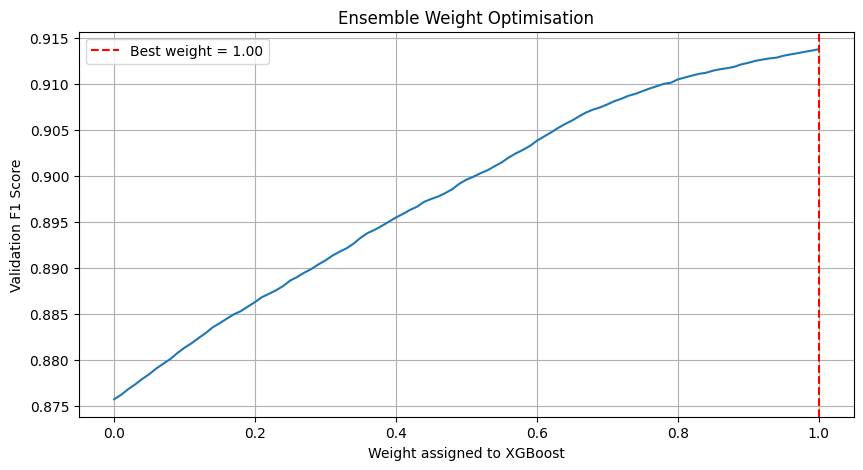

In [42]:
from sklearn.metrics import f1_score

weights = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00
best_weight = 0.5
best_score = 0

scores = []

for w in weights:
    # Ensemble probability = w * XGB_proba + (1-w) * LR_proba
    ensemble_proba = w * proba_xgb_val + (1 - w) * proba_lr_val
    # Threshold at 0.5 for simplicity (we can tune later, but we'll just maximise F1)
    ensemble_pred = (ensemble_proba >= 0.5).astype(int)
    f1 = f1_score(y_val, ensemble_pred)
    scores.append(f1)
    if f1 > best_score:
        best_score = f1
        best_weight = w

print(f"✅ Optimal XGBoost weight: {best_weight:.2f}")
print(f"   Optimal LR weight: {1 - best_weight:.2f}")
print(f"   Best validation F1: {best_score:.4f}")

# Plot weight vs F1
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(weights, scores)
plt.axvline(best_weight, color='red', linestyle='--', label=f'Best weight = {best_weight:.2f}')
plt.xlabel('Weight assigned to XGBoost')
plt.ylabel('Validation F1 Score')
plt.title('Ensemble Weight Optimisation')
plt.legend()
plt.grid()
plt.show()

In [43]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score

# Define scoring
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'roc_auc': make_scorer(roc_auc_score)
}

def evaluate_ensemble(weight_xgb, X, y, cv=5):
    """
    Runs CV for LR and XGB separately, then combines their out-of-fold probabilities
    using the given weight, and computes CV scores for the ensemble.
    """
    # We'll store out-of-fold predictions for each fold
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
    y_true_list = []
    ensemble_proba_list = []
    
    for train_idx, val_idx in skf.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
        
        # Fit LR on this fold
        lr_fold = Pipeline([
            ('preprocessor', preprocessor),
            ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
        ])
        lr_fold.fit(X_train_fold, y_train_fold)
        proba_lr = lr_fold.predict_proba(X_val_fold)[:, 1]
        
        # Fit XGB on this fold
        xgb_fold = Pipeline([
            ('preprocessor', preprocessor),
            ('clf', xgb.XGBClassifier(
                n_estimators=200, learning_rate=0.1, max_depth=6,
                scale_pos_weight=scale_pos_weight, tree_method='hist',
                n_jobs=1, random_state=42, use_label_encoder=False, eval_metric='logloss'
            ))
        ])
        xgb_fold.fit(X_train_fold, y_train_fold)
        proba_xgb = xgb_fold.predict_proba(X_val_fold)[:, 1]
        
        # Ensemble
        ensemble_proba = weight_xgb * proba_xgb + (1 - weight_xgb) * proba_lr
        
        y_true_list.extend(y_val_fold)
        ensemble_proba_list.extend(ensemble_proba)
    
    # Convert to arrays
    y_true_arr = np.array(y_true_list)
    y_proba_arr = np.array(ensemble_proba_list)
    y_pred_arr = (y_proba_arr >= 0.5).astype(int)
    
    # Compute metrics
    metrics = {
        'accuracy': accuracy_score(y_true_arr, y_pred_arr),
        'precision': precision_score(y_true_arr, y_pred_arr),
        'recall': recall_score(y_true_arr, y_pred_arr),
        'f1': f1_score(y_true_arr, y_pred_arr),
        'roc_auc': roc_auc_score(y_true_arr, y_proba_arr)
    }
    return metrics

# Evaluate ensemble with the optimal weight found earlier
print(f"Evaluating ensemble with weight XGB = {best_weight:.2f} ...")
ensemble_scores = evaluate_ensemble(best_weight, X, y, cv=5)

print("\n===== 5-Fold CV Ensemble Performance =====")
for metric, score in ensemble_scores.items():
    print(f"{metric.capitalize():10}: {score:.4f}")

Evaluating ensemble with weight XGB = 1.00 ...

===== 5-Fold CV Ensemble Performance =====
Accuracy  : 0.8689
Precision : 0.9629
Recall    : 0.8479
F1        : 0.9018
Roc_auc   : 0.9565


In [46]:
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score

# --- Preprocessor (define once) ---
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# --- Logistic Regression pipeline ---
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# --- XGBoost pipeline ---
neg, pos = np.bincount(y)
scale_pos_weight = neg / pos
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', xgb.XGBClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        n_jobs=1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# Get out-of-fold probabilities (this automatically clones the preprocessor per fold)
print("Getting out-of-fold predictions for Logistic Regression...")
proba_lr_oof = cross_val_predict(
    lr_pipeline, X, y,
    cv=5,
    method='predict_proba',
    n_jobs=-1,
    verbose=1
)[:, 1]

print("Getting out-of-fold predictions for XGBoost...")
proba_xgb_oof = cross_val_predict(
    xgb_pipeline, X, y,
    cv=5,
    method='predict_proba',
    n_jobs=-1,
    verbose=1
)[:, 1]

print("✅ Out-of-fold probabilities obtained.")

Getting out-of-fold predictions for Logistic Regression...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.5s finished


Getting out-of-fold predictions for XGBoost...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


✅ Out-of-fold probabilities obtained.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.1min finished


✅ Optimal XGBoost weight: 1.00
   Corresponding LR weight: 0.00
   Best validation F1: 0.9142


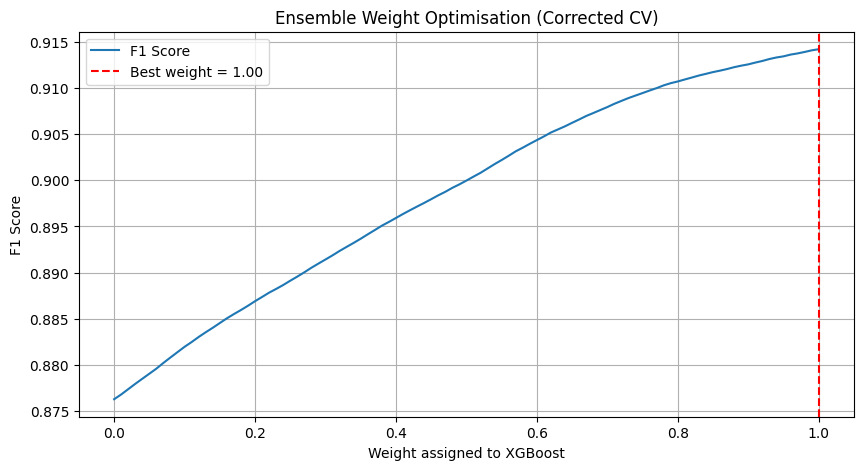


===== Best Ensemble Performance (5-Fold CV) =====
Accuracy : 0.8840
Precision: 0.9623
Recall   : 0.8707
F1       : 0.9142
ROC-AUC  : 0.9623


In [47]:
import matplotlib.pyplot as plt

weights = np.linspace(0, 1, 101)
best_weight = 0.5
best_f1 = 0
results = []

for w in weights:
    # Ensemble out-of-fold probabilities
    ensemble_proba = w * proba_xgb_oof + (1 - w) * proba_lr_oof
    ensemble_pred = (ensemble_proba >= 0.5).astype(int)
    
    f1 = f1_score(y, ensemble_pred)
    acc = accuracy_score(y, ensemble_pred)
    prec = precision_score(y, ensemble_pred)
    rec = recall_score(y, ensemble_pred)
    auc = roc_auc_score(y, ensemble_proba)
    
    results.append((w, acc, prec, rec, f1, auc))
    
    if f1 > best_f1:
        best_f1 = f1
        best_weight = w

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results, columns=['weight_xgb', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

print(f"✅ Optimal XGBoost weight: {best_weight:.2f}")
print(f"   Corresponding LR weight: {1 - best_weight:.2f}")
print(f"   Best validation F1: {best_f1:.4f}")

# Plot F1 vs weight
plt.figure(figsize=(10,5))
plt.plot(results_df['weight_xgb'], results_df['f1'], label='F1 Score')
plt.axvline(best_weight, color='red', linestyle='--', label=f'Best weight = {best_weight:.2f}')
plt.xlabel('Weight assigned to XGBoost')
plt.ylabel('F1 Score')
plt.title('Ensemble Weight Optimisation (Corrected CV)')
plt.legend()
plt.grid()
plt.show()

# Display the best row
best_row = results_df[results_df['weight_xgb'] == best_weight].iloc[0]
print("\n===== Best Ensemble Performance (5-Fold CV) =====")
print(f"Accuracy : {best_row['accuracy']:.4f}")
print(f"Precision: {best_row['precision']:.4f}")
print(f"Recall   : {best_row['recall']:.4f}")
print(f"F1       : {best_row['f1']:.4f}")
print(f"ROC-AUC  : {best_row['roc_auc']:.4f}")

In [49]:
# With LR as a feature
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score

# Assume X and y are already defined (full training data)
# We'll use the same preprocessor for both models

# --- Preprocessor ---
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# --- Logistic Regression pipeline ---
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])

# --- XGBoost pipeline (to be used inside CV) ---
neg, pos = np.bincount(y)
scale_pos_weight = neg / pos
xgb_clf = xgb.XGBClassifier(
    n_estimators=2500,
    learning_rate=0.02,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    n_jobs=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# --- Custom cross-validation for the stacked model ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_list = []
y_proba_list = []

print("Running 5-fold CV with LR probability as a feature for XGBoost...")

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]
    
    # 1. Train LR on this fold's training data
    lr_pipeline.fit(X_train_fold, y_train_fold)
    # 2. Get LR probabilities on the validation fold
    lr_proba_val = lr_pipeline.predict_proba(X_val_fold)[:, 1]
    # 3. Also get LR probabilities on the training fold (to add as feature for XGBoost training)
    lr_proba_train = lr_pipeline.predict_proba(X_train_fold)[:, 1]
    
    # 4. Add LR probability as a new column to both training and validation sets
    X_train_aug = X_train_fold.copy()
    X_val_aug = X_val_fold.copy()
    X_train_aug['lr_proba'] = lr_proba_train
    X_val_aug['lr_proba'] = lr_proba_val
    
    # 5. Preprocess the augmented data (the preprocessor will handle the new column as numeric)
    # We need to define a new preprocessor that includes the 'lr_proba' column as a numeric feature.
    # Since 'lr_proba' is already numeric and has no missing values, we can just treat it as a numeric column.
    # We'll adjust the preprocessor manually for this fold.
    
    # Actually, it's easier to manually scale/process the original features and then add the probability.
    # Let's use the preprocessor on the original features (without lr_proba) and then concatenate.
    
    # Transform original features using the preprocessor fitted on the training fold
    # We must fit the preprocessor on the training fold only.
    preprocessor_clone = ColumnTransformer([
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])
    X_train_processed = preprocessor_clone.fit_transform(X_train_fold)
    X_val_processed = preprocessor_clone.transform(X_val_fold)
    
    # Now add the LR probability as an additional feature
    X_train_aug_processed = np.hstack([X_train_processed, lr_proba_train.reshape(-1, 1)])
    X_val_aug_processed = np.hstack([X_val_processed, lr_proba_val.reshape(-1, 1)])
    
    # 6. Train XGBoost on the augmented training set
    xgb_fold = xgb_clf
    xgb_fold.fit(X_train_aug_processed, y_train_fold)
    
    # 7. Predict probabilities on validation
    y_pred_proba = xgb_fold.predict_proba(X_val_aug_processed)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    y_true_list.extend(y_val_fold)
    y_proba_list.extend(y_pred_proba)
    
    print(f"  Fold {fold+1}: F1 = {f1_score(y_val_fold, y_pred):.4f}")
    print(f"  Fold {fold+1}: ROC-AUC = {roc_auc_score(y_val_fold, y_pred_proba):.4f}")

# Overall metrics
y_true_arr = np.array(y_true_list)
y_proba_arr = np.array(y_proba_list)
y_pred_arr = (y_proba_arr >= 0.5).astype(int)

print("\n===== 5-Fold CV Performance (LR probability as feature for XGB) =====")
print(f"Accuracy : {accuracy_score(y_true_arr, y_pred_arr):.4f}")
print(f"Precision: {precision_score(y_true_arr, y_pred_arr):.4f}")
print(f"Recall   : {recall_score(y_true_arr, y_pred_arr):.4f}")
print(f"F1       : {f1_score(y_true_arr, y_pred_arr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_true_arr, y_proba_arr):.4f}")

Running 5-fold CV with LR probability as a feature for XGBoost...
  Fold 1: F1 = 0.9115
  Fold 1: ROC-AUC = 0.9611
  Fold 2: F1 = 0.9124
  Fold 2: ROC-AUC = 0.9616
  Fold 3: F1 = 0.9129
  Fold 3: ROC-AUC = 0.9618
  Fold 4: F1 = 0.9132
  Fold 4: ROC-AUC = 0.9628
  Fold 5: F1 = 0.9130
  Fold 5: ROC-AUC = 0.9614

===== 5-Fold CV Performance (LR probability as feature for XGB) =====
Accuracy : 0.8821
Precision: 0.9629
Recall   : 0.8673
F1       : 0.9126
ROC-AUC  : 0.9617


## Feature Engineering function


In [81]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
import xgboost as xgb

def evaluate_model(
    X, y,
    feature_engineering=None,
    model_type='xgb',                # 'xgb' or 'lgbm'
    xgb_params=None,
    lgbm_params=None,
    lr_params=None,
    method='stacking',               # 'plain_xgb', 'weighted_ensemble', 'stacking'
    cv=5,
    random_state=42,
    verbose=True,
    return_model=False,              # if True, return fitted model on full data
    test_data=None,                  # optional test DataFrame (no target)
    threshold=0.5,                   # threshold for binary classification
):
    """
    Cross-validate and/or train a binary classifier with optional feature engineering,
    stacking, and test prediction.

    Parameters
    ----------
    X : pd.DataFrame
        Training features (excluding target).
    y : pd.Series or np.ndarray
        Training target labels.
    feature_engineering : callable, optional
        Function that takes X and returns a new DataFrame with added features.
    model_type : str, {'xgb', 'lgbm'}
        Which gradient boosting model to use (second model in stacking/ensemble).
    xgb_params : dict, optional
        XGBClassifier parameters.
    lgbm_params : dict, optional
        LGBMClassifier parameters.
    lr_params : dict, optional
        LogisticRegression parameters.
    method : str, {'plain_xgb', 'weighted_ensemble', 'stacking'}
        - 'plain_xgb' : only the boosting model (XGB or LGBM) on engineered features.
        - 'weighted_ensemble' : weighted average of LR and boosting model.
        - 'stacking' : LR probability added as a feature to the boosting model.
    cv : int
        Number of folds for cross-validation. Set to 0 to skip CV.
    random_state : int
        Seed.
    verbose : bool
        Print progress.
    return_model : bool
        If True, retrain the model on the full training data and return it.
    test_data : pd.DataFrame, optional
        Test features (no target). If provided, predictions will be generated.
    threshold : float
        Decision threshold for converting probabilities to labels.

    Returns
    -------
    dict
        Always contains:
            - 'cv_metrics' (if cv>0): dict with 'accuracy', 'precision', ... and 'fold_metrics'.
            - 'model' (if return_model): fitted model (pipeline or tuple for weighted ensemble).
            - 'test_predictions' (if test_data provided): DataFrame with id, predicted_label, probability.
    """
    # --- Default parameters ---
    if xgb_params is None:
        xgb_params = {
            'n_estimators': 200,
            'learning_rate': 0.1,
            'max_depth': 6,
            'tree_method': 'hist',
            'n_jobs': 1,
            'random_state': random_state,
            'use_label_encoder': False,
            'eval_metric': 'logloss'
        }
    if lgbm_params is None:
        lgbm_params = {
            'n_estimators': 200,
            'learning_rate': 0.1,
            'max_depth': 6,
            'num_leaves': 31,
            'objective': 'binary',
            'metric': 'binary_logloss',
            'boosting_type': 'gbdt',
            'n_jobs': 1,
            'random_state': random_state,
            'verbosity': -1
        }
    if lr_params is None:
        lr_params = {
            'class_weight': 'balanced',
            'max_iter': 1000,
            'random_state': random_state
        }

    # Apply feature engineering (if any)
    if feature_engineering is not None:
        X = feature_engineering(X)
        if test_data is not None:
            test_data = feature_engineering(test_data)

    # Identify numeric and categorical columns
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object']).columns.tolist()

    # Preprocessor for original features
    num_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ])
    preprocessor = ColumnTransformer([
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

    # Helper: create the boosting classifier
    def create_boosting_model(params):
        if model_type == 'xgb':
            # Compute scale_pos_weight for imbalance
            neg, pos = np.bincount(y)
            params['scale_pos_weight'] = neg / pos
            return xgb.XGBClassifier(**params)
        else:  # lgbm
            import lightgbm as lgb
            # LGBM uses class_weight parameter
            neg, pos = np.bincount(y)
            pos_weight = neg / pos
            params['class_weight'] = {0: 1.0, 1: pos_weight}
            return lgb.LGBMClassifier(**params)

    # Helper: train boosting model (with optional stacking)
    def fit_boosting(X_train_processed, y_train, X_val_processed, y_val=None, lr_proba_train=None):
        # Prepare augmented features
        if method == 'stacking' and lr_proba_train is not None:
            # We need LR probabilities on training set
            X_train_aug = np.hstack([X_train_processed, lr_proba_train.reshape(-1, 1)])
            X_val_aug = np.hstack([X_val_processed, lr_proba_val.reshape(-1, 1)]) if y_val is not None else None
        else:
            X_train_aug = X_train_processed
            X_val_aug = X_val_processed if y_val is not None else None

        # Instantiate model
        if model_type == 'xgb':
            model = create_boosting_model(xgb_params)
        else:
            model = create_boosting_model(lgbm_params)

        # Fit
        if y_val is not None:
            # For early stopping (optional), but we'll just fit without validation
            model.fit(X_train_aug, y_train)
        else:
            model.fit(X_train_aug, y_train)
        return model, X_train_aug, X_val_aug

    # -------------------------------
    #   CROSS-VALIDATION (if cv>0)
    # -------------------------------
    cv_metrics = None
    if cv > 0:
        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
        y_true_list = []
        y_proba_list = []
        fold_metrics = []

        if method == 'weighted_ensemble':
            oof_lr_proba = np.zeros(len(X))
            oof_boost_proba = np.zeros(len(X))
            y_true_all = np.zeros(len(X))

        if verbose:
            print(f"Running {cv}-fold CV with method='{method}', model='{model_type}'...")

        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
            X_train = X.iloc[train_idx]
            X_val = X.iloc[val_idx]
            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx]

            # Preprocess
            preprocessor_clone = ColumnTransformer([
                ('num', num_transformer, num_cols),
                ('cat', cat_transformer, cat_cols)
            ])
            X_train_processed = preprocessor_clone.fit_transform(X_train)
            X_val_processed = preprocessor_clone.transform(X_val)

            # Logistic Regression
            lr = LogisticRegression(**lr_params)
            lr.fit(X_train_processed, y_train)
            lr_proba_train = lr.predict_proba(X_train_processed)[:, 1]
            lr_proba_val = lr.predict_proba(X_val_processed)[:, 1]

            # Boosting model (with stacking if method=='stacking')
            if method == 'stacking':
                X_train_aug = np.hstack([X_train_processed, lr_proba_train.reshape(-1, 1)])
                X_val_aug = np.hstack([X_val_processed, lr_proba_val.reshape(-1, 1)])
            else:
                X_train_aug = X_train_processed
                X_val_aug = X_val_processed

            boost_model = create_boosting_model(xgb_params if model_type=='xgb' else lgbm_params)
            boost_model.fit(X_train_aug, y_train)
            boost_proba_val = boost_model.predict_proba(X_val_aug)[:, 1]

            if method == 'weighted_ensemble':
                oof_lr_proba[val_idx] = lr_proba_val
                oof_boost_proba[val_idx] = boost_proba_val
                y_true_all[val_idx] = y_val
                # We'll compute later
            else:
                y_true_list.extend(y_val)
                y_proba_list.extend(boost_proba_val)
                y_pred = (boost_proba_val >= threshold).astype(int)
                fold_f1 = f1_score(y_val, y_pred)
                fold_roc_auc = roc_auc_score(y_val, boost_proba_val)
                fold_metrics.append({
                    'fold': fold+1,
                    'f1': fold_f1,
                    'roc_auc': fold_roc_auc
                })
                if verbose:
                    print(f"  Fold {fold+1} | F1: {fold_f1:.6f} | ROC-AUC: {fold_roc_auc:.6f}")

        # Compute CV metrics
        if method == 'weighted_ensemble':
            # Find optimal weight (for boost model)
            weights = np.linspace(0, 1, 101)
            best_weight = 0.5
            best_f1 = 0
            for w in weights:
                ensemble_proba = w * oof_boost_proba + (1 - w) * oof_lr_proba
                ensemble_pred = (ensemble_proba >= threshold).astype(int)
                f1 = f1_score(y_true_all, ensemble_pred)
                if f1 > best_f1:
                    best_f1 = f1
                    best_weight = w
            ensemble_proba_all = best_weight * oof_boost_proba + (1 - best_weight) * oof_lr_proba
            y_pred_all = (ensemble_proba_all >= threshold).astype(int)
            cv_metrics = {
                'accuracy': accuracy_score(y_true_all, y_pred_all),
                'precision': precision_score(y_true_all, y_pred_all),
                'recall': recall_score(y_true_all, y_pred_all),
                'f1': f1_score(y_true_all, y_pred_all),
                'roc_auc': roc_auc_score(y_true_all, ensemble_proba_all),
                'best_weight_boost': best_weight
            }
            if verbose:
                print(f"Optimal weight for boosting model: {best_weight:.2f}")
        else:
            y_true_all = np.array(y_true_list)
            y_proba_all = np.array(y_proba_list)
            y_pred_all = (y_proba_all >= threshold).astype(int)
            cv_metrics = {
                'accuracy': accuracy_score(y_true_all, y_pred_all),
                'precision': precision_score(y_true_all, y_pred_all),
                'recall': recall_score(y_true_all, y_pred_all),
                'f1': f1_score(y_true_all, y_pred_all),
                'roc_auc': roc_auc_score(y_true_all, y_proba_all),
                'fold_metrics': pd.DataFrame(fold_metrics)
            }

    # -------------------------------------------------
    #   TRAIN ON FULL DATA (if return_model or test_data)
    # -------------------------------------------------
    model = None
    test_predictions = None

    if return_model or (test_data is not None):
        if verbose:
            print("Training on full dataset...")

        # Preprocess full X
        X_processed_full = preprocessor.fit_transform(X)
        lr_full = LogisticRegression(**lr_params)
        lr_full.fit(X_processed_full, y)
        lr_proba_full = lr_full.predict_proba(X_processed_full)[:, 1]

        # Prepare augmented features for boosting
        if method == 'stacking':
            X_aug_full = np.hstack([X_processed_full, lr_proba_full.reshape(-1, 1)])
        else:
            X_aug_full = X_processed_full

        boost_full = create_boosting_model(xgb_params if model_type=='xgb' else lgbm_params)
        boost_full.fit(X_aug_full, y)

        # Store model(s)
        if method == 'weighted_ensemble':
            model = (lr_full, boost_full)  # tuple of both models
        else:
            model = boost_full  # just the boosting model

        # Predict on test_data if provided
        if test_data is not None:
            if verbose:
                print("Predicting on test data...")
            # Preprocess test
            X_test_processed = preprocessor.transform(test_data)
            lr_proba_test = lr_full.predict_proba(X_test_processed)[:, 1]

            if method == 'stacking':
                X_test_aug = np.hstack([X_test_processed, lr_proba_test.reshape(-1, 1)])
            else:
                X_test_aug = X_test_processed

            if method == 'weighted_ensemble':
                boost_proba_test = boost_full.predict_proba(X_test_aug)[:, 1]
                ensemble_proba = best_weight * boost_proba_test + (1 - best_weight) * lr_proba_test
                test_proba = ensemble_proba
            else:
                test_proba = boost_full.predict_proba(X_test_aug)[:, 1]

            test_pred = (test_proba >= threshold).astype(int)

            # Build submission DataFrame
            if 'id' in test_data.columns:
                test_ids = test_data['id']
            else:
                test_ids = np.arange(len(test_data))
            test_predictions = pd.DataFrame({
                'id': test_ids,
                'predicted_label': test_pred,
                'probability': test_proba
            })

    # Prepare result dict
    result = {}
    if cv > 0:
        result['cv_metrics'] = cv_metrics
    if return_model:
        result['model'] = model
    if test_predictions is not None:
        result['test_predictions'] = test_predictions

    return result

In [51]:
X = df.drop(columns=['id', 'addicted_label'])
y = df['addicted_label']

In [52]:
help(evaluate_model)

Help on function evaluate_model in module __main__:

evaluate_model(
    X,
    y,
    feature_engineering=None,
    xgb_params=None,
    lr_params=None,
    method='stacking',
    cv=5,
    random_state=42,
    verbose=True
)
    Perform cross-validation with optional feature engineering and model stacking.

    Parameters
    ----------
    X : pd.DataFrame
        Original features (excluding target).
    y : pd.Series or np.ndarray
        Target labels.
    feature_engineering : callable, optional
        Function that takes X and returns a new DataFrame with added features.
        Must be stateless (no fitting/transforming using global statistics).
    xgb_params : dict, optional
        Parameters for XGBClassifier (default: n_estimators=200, lr=0.1, max_depth=6, etc.)
    lr_params : dict, optional
        Parameters for LogisticRegression (default: class_weight='balanced', max_iter=1000)
    method : str, one of {'plain_xgb', 'weighted_ensemble', 'stacking'}
        - 'plain_

In [53]:
# Baseline: no extra features, default XGBoost
results_baseline = evaluate_model(
    X, y,
    feature_engineering=None,
    method='stacking',   # or 'plain_xgb'
    verbose=True,
    xgb_params={'n_estimators': 3000, 'max_depth': 6, 'learning_rate': 0.03}
)
print("Baseline ROC-AUC:", results_baseline['roc_auc'])

Running 5-fold CV with method='stacking'...
  Fold 1 | F1: 0.9155 | ROC-AUC: 0.9623
  Fold 2 | F1: 0.9161 | ROC-AUC: 0.9629
  Fold 3 | F1: 0.9166 | ROC-AUC: 0.9631
  Fold 4 | F1: 0.9168 | ROC-AUC: 0.9639
  Fold 5 | F1: 0.9166 | ROC-AUC: 0.9626
Baseline ROC-AUC: 0.9629567758058262


In [54]:
def add_poly_features(X):
    X_new = X.copy()
    # Example: square of daily_screen_time_hours
    X_new['screen_time_sq'] = X_new['daily_screen_time_hours'] ** 2
    # Example: interaction between social_media and gaming
    X_new['social_gaming_ratio'] = X_new['social_media_hours'] / (X_new['gaming_hours'] + 1e-5)
    # Example: log of notifications
    X_new['log_notifications'] = np.log(X_new['notifications_per_day'] + 1)
    return X_new

# Experiment 1: add polynomial features
results_poly = evaluate_model(
    X, y,
    feature_engineering=add_poly_features,
    method='stacking',
    xgb_params={'n_estimators': 3000, 'max_depth': 8, 'learning_rate': 0.06, "is_unbalance": True},
    verbose=True
)
print("With poly features ROC-AUC:", results_poly['roc_auc'])

Running 5-fold CV with method='stacking'...
  Fold 1 | F1: 0.9220 | ROC-AUC: 0.9613
  Fold 2 | F1: 0.9230 | ROC-AUC: 0.9620
  Fold 3 | F1: 0.9226 | ROC-AUC: 0.9620
  Fold 4 | F1: 0.9229 | ROC-AUC: 0.9627
  Fold 5 | F1: 0.9222 | ROC-AUC: 0.9615
With poly features ROC-AUC: 0.961923979830078


In [57]:
def add_poly_features(X):
    X_new = X.copy()
    # Example: square of daily_screen_time_hours
    X_new['daily_screen_x_social_media'] = X_new['daily_screen_time_hours'] * np.log1p( X_new['social_media_hours'])
    return X_new

# Experiment 2: try plain XGBoost (without LR stacking) with same features
results_plain = evaluate_model(
    X, y,
    feature_engineering=add_poly_features,
    method='stacking',
    xgb_params={'n_estimators': 10000, 'learning_rate': 0.03, "is_unbalance": True},
    verbose=True
)
print("Plain XGB (poly) ROC-AUC:", results_plain['roc_auc'])

Running 5-fold CV with method='stacking'...
  Fold 1 | F1: 0.9206 | ROC-AUC: 0.9621
  Fold 2 | F1: 0.9211 | ROC-AUC: 0.9627
  Fold 3 | F1: 0.9212 | ROC-AUC: 0.9629
  Fold 4 | F1: 0.9215 | ROC-AUC: 0.9635
  Fold 5 | F1: 0.9210 | ROC-AUC: 0.9625
Plain XGB (poly) ROC-AUC: 0.9627275959314484


In [58]:
def add_poly_features(X):
    X_new = X.copy()
    # Example: square of daily_screen_time_hours
    X_new['daily_screen_x_social_media'] = X_new['daily_screen_time_hours'] * np.log1p( X_new['social_media_hours'])
    return X_new

xgb_model_params_new = {
    'n_estimators': 10000,
    'learning_rate': 0.03,
    'max_depth': 6,
    'scale_pos_weight': scale_pos_weight,
    'tree_method': 'hist',
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    'n_jobs': -1,
    'random_state': 42,
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'early_stopping_rounds': 50
}

# Experiment 2: try plain XGBoost (without LR stacking) with same features
results_plain = evaluate_model(
    X, y,
    feature_engineering=add_poly_features,
    method='stacking',
    xgb_params=xgb_model_params_new,
    verbose=True
)
print("Plain XGB (poly) ROC-AUC:", results_plain['roc_auc'])

Running 5-fold CV with method='stacking'...
  Fold 1 | F1: 0.9207 | ROC-AUC: 0.9618
  Fold 2 | F1: 0.9214 | ROC-AUC: 0.9623
  Fold 3 | F1: 0.9215 | ROC-AUC: 0.9627
  Fold 4 | F1: 0.9220 | ROC-AUC: 0.9633
  Fold 5 | F1: 0.9216 | ROC-AUC: 0.9623
Plain XGB (poly) ROC-AUC: 0.9624917113204952


In [66]:
num_cols

['age',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time']

In [68]:
def add_poly_features(X):
    X_new = X.copy()
    # Example: square of daily_screen_time_hours
    # X_new['daily_screen_x_social_media'] = X_new['daily_screen_time_hours'] * np.log1p( X_new['social_media_hours'])
    # X_new = X_new.drop(columns=['social_media_hours'])                    
    X_new["weekday_screen_time"] = (
        X_new['daily_screen_time_hours'] -
        X_new["weekend_screen_time"]
    )
    return X_new

xgb_model_params_new = {
    'n_estimators': 4500,
    'learning_rate': 0.03,
    'max_depth': 6,
    'scale_pos_weight': scale_pos_weight,
    'tree_method': 'hist',
    "reg_alpha": 5,
    "reg_lambda": 5,
    'n_jobs': -1,
    'random_state': 42,
    # 'use_label_encoder': False,
    'eval_metric': 'logloss',
    # 'early_stopping_rounds': 50
}

# Experiment 2: try plain XGBoost (without LR stacking) with same features
results_plain = evaluate_model(
    X, y,
    feature_engineering=add_poly_features,
    method='stacking',
    xgb_params=xgb_model_params_new,
    verbose=True
)   
print("Plain XGB (poly) ROC-AUC:", results_plain['roc_auc'])

Running 5-fold CV with method='stacking'...
  Fold 1 | F1: 0.9169 | ROC-AUC: 0.9628
  Fold 2 | F1: 0.9175 | ROC-AUC: 0.9635
  Fold 3 | F1: 0.9180 | ROC-AUC: 0.9637
  Fold 4 | F1: 0.9178 | ROC-AUC: 0.9644
  Fold 5 | F1: 0.9176 | ROC-AUC: 0.9632
Plain XGB (poly) ROC-AUC: 0.9635258788614862


In [71]:
# num_cols = [
#     'age',
#     'daily_screen_time_hours',
#     'social_media_hours',
#     'gaming_hours',
#     'work_study_hours',
#     'sleep_hours',
#     'notifications_per_day',
#     'app_opens_per_day',
#     'weekend_screen_time'
# ]

def add_poly_features(X):
    X_new = X.copy()
    # Example: square of daily_screen_time_hours
    # X_new['daily_screen_x_social_media'] = X_new['daily_screen_time_hours'] * np.log1p( X_new['social_media_hours'])
    # X_new = X_new.drop(columns=['social_media_hours'])                    
    X_new['app_opens_ratio'] = X_new['app_opens_per_day'] / (X_new['daily_screen_time_hours'] + 1)
    return X_new

xgb_model_params_new = {
    'n_estimators': 4500,
    'learning_rate': 0.03,
    'scale_pos_weight': scale_pos_weight,
    'tree_method': 'hist',
    "reg_alpha": 5,
    "reg_lambda": 5,
    'n_jobs': -1,
    'random_state': 42,
    # 'use_label_encoder': False,           
    'eval_metric': 'logloss',
    # 'early_stopping_rounds': 50
}

# Experiment 2: try plain XGBoost (without LR stacking) with same features
results_plain = evaluate_model(
    X, y,
    feature_engineering=add_poly_features,
    method='stacking',
    xgb_params=xgb_model_params_new,
    verbose=True
)   
print("Plain XGB (poly) ROC-AUC:", results_plain['roc_auc'])

Running 5-fold CV with method='stacking'...
  Fold 1 | F1: 0.9167 | ROC-AUC: 0.9628
  Fold 2 | F1: 0.9178 | ROC-AUC: 0.9635
  Fold 3 | F1: 0.9181 | ROC-AUC: 0.9637
  Fold 4 | F1: 0.9181 | ROC-AUC: 0.9644
  Fold 5 | F1: 0.9177 | ROC-AUC: 0.9631
Plain XGB (poly) ROC-AUC: 0.9635066844683478


In [79]:
# num_cols = [
#     'age',
#     'daily_screen_time_hours',
#     'social_media_hours',
#     'gaming_hours',
#     'work_study_hours',
#     'sleep_hours',
#     'notifications_per_day',
#     'app_opens_per_day',
#     'weekend_screen_time'
# ]

def add_poly_features(X):
    X_new = X.copy()
    # Example: square of daily_screen_time_hours
    # X_new['daily_screen_x_social_media'] = X_new['daily_screen_time_hours'] * np.log1p( X_new['social_media_hours'])
    # X_new = X_new.drop(columns=['social_media_hours'])                    
    # X_new['app_opens_ratio'] = X_new['app_opens_per_day'] / (X_new['daily_screen_time_hours'] + 1)



    return X_new

xgb_model_params_new = {
    'n_estimators': 5000,
    'learning_rate': 0.03,
    'scale_pos_weight': scale_pos_weight,
    'tree_method': 'hist',
    "reg_alpha": 5,
    "reg_lambda": 5,
    'n_jobs': -1,
    'random_state': 42,
    # 'use_label_encoder': False,           
    'eval_metric': 'logloss',
    # 'early_stopping_rounds': 50
}

# Experiment 2: try plain XGBoost (without LR stacking) with same features
results_plain = evaluate_model(
    X, y,
    feature_engineering=add_poly_features,
    model_type="lgbm",
    method='stacking',
    xgb_params=xgb_model_params_new,
    lgbm_params=xgb_model_params_new,
    verbose=True,
    test_data=test_df
)   
print("Plain LGB (poly) ROC-AUC:", results_plain['cv_metrics']['roc_auc'])

Running 5-fold CV with method='stacking', model='lgbm'...
  Fold 1 | F1: 0.8831 | ROC-AUC: 0.9625
  Fold 2 | F1: 0.8845 | ROC-AUC: 0.9633
  Fold 3 | F1: 0.8854 | ROC-AUC: 0.9635
  Fold 4 | F1: 0.8845 | ROC-AUC: 0.9642
  Fold 5 | F1: 0.8850 | ROC-AUC: 0.9629
Training on full dataset...
Predicting on test data...
Plain XGB (poly) ROC-AUC: 0.9632815288942982


In [80]:
# num_cols = [
#     'age',
#     'daily_screen_time_hours',
#     'social_media_hours',
#     'gaming_hours',
#     'work_study_hours',
#     'sleep_hours',
#     'notifications_per_day',
#     'app_opens_per_day',
#     'weekend_screen_time'
# ]

def add_poly_features(X):
    X_new = X.copy()
    # Example: square of daily_screen_time_hours
    # X_new['daily_screen_x_social_media'] = X_new['daily_screen_time_hours'] * np.log1p( X_new['social_media_hours'])
    # X_new = X_new.drop(columns=['social_media_hours'])                    
    # X_new['app_opens_ratio'] = X_new['app_opens_per_day'] / (X_new['daily_screen_time_hours'] + 1)



    return X_new

xgb_model_params_new = {
    'n_estimators': 5000,
    'learning_rate': 0.03,
    'scale_pos_weight': scale_pos_weight,
    # 'tree_method': 'hist',
    "reg_alpha": 5,
    "reg_lambda": 5,
    'n_jobs': -1,
    'random_state': 42,
    # 'use_label_encoder': False,           
    # 'eval_metric': 'logloss',
    # 'early_stopping_rounds': 50
}

# Experiment 2: try plain XGBoost (without LR stacking) with same features
results_plain = evaluate_model(
    X, y,
    feature_engineering=add_poly_features,
    model_type="lgbm",
    method='plain_xgb',
    xgb_params=xgb_model_params_new,
    lgbm_params=xgb_model_params_new,
    verbose=True,
    test_data=test_df
)   
print("Plain LGB (poly) ROC-AUC:", results_plain['cv_metrics']['roc_auc'])

Running 5-fold CV with method='plain_xgb', model='lgbm'...
  Fold 1 | F1: 0.8835 | ROC-AUC: 0.9626
  Fold 2 | F1: 0.8848 | ROC-AUC: 0.9633
  Fold 3 | F1: 0.8852 | ROC-AUC: 0.9636
  Fold 4 | F1: 0.8844 | ROC-AUC: 0.9643
  Fold 5 | F1: 0.8847 | ROC-AUC: 0.9630
Training on full dataset...
Predicting on test data...
Plain LGB (poly) ROC-AUC: 0.9633505257946315


In [ ]:
# num_cols = [
#     'age',
#     'daily_screen_time_hours',
#     'social_media_hours',
#     'gaming_hours',
#     'work_study_hours',
#     'sleep_hours',
#     'notifications_per_day',
#     'app_opens_per_day',
#     'weekend_screen_time'
# ]

def add_poly_features(X):
    X_new = X.copy()
    # Example: square of daily_screen_time_hours
    # X_new['daily_screen_x_social_media'] = X_new['daily_screen_time_hours'] * np.log1p( X_new['social_media_hours'])
    # X_new = X_new.drop(columns=['social_media_hours'])                    
    # X_new['app_opens_ratio'] = X_new['app_opens_per_day'] / (X_new['daily_screen_time_hours'] + 1)



    return X_new

xgb_model_params_new = {
    'n_estimators': 5000,
    'learning_rate': 0.03,
    'scale_pos_weight': scale_pos_weight,
    # 'tree_method': 'hist',
    "reg_alpha": 5,
    "reg_lambda": 5,
    'n_jobs': -1,
    'random_state': 42,
    # 'use_label_encoder': False,           
    # 'eval_metric': 'logloss',
    # 'early_stopping_rounds': 50
}

# Experiment 2: try plain XGBoost (without LR stacking) with same features
results_plain = evaluate_model(
    X, y,
    feature_engineering=add_poly_features,
    model_type="lgbm",
    method='plain_xgb',
    xgb_params=xgb_model_params_new,
    lgbm_params=xgb_model_params_new,
    verbose=True,
    test_data=test_df
)   
print("Plain LGB (poly) ROC-AUC:", results_plain['cv_metrics']['roc_auc'])

In [82]:
corr_with_target = df.select_dtypes(include=['int64', 'float64']).corrwith(df['addicted_label']).sort_values(ascending=False)
print("Correlation with addicted_label:\n", corr_with_target)

Correlation with addicted_label:
 addicted_label             1.000000
daily_screen_time_hours    0.611398
weekend_screen_time        0.589903
social_media_hours         0.532409
work_study_hours           0.251416
gaming_hours               0.205283
app_opens_per_day          0.063482
sleep_hours                0.042545
age                        0.004043
id                         0.001097
notifications_per_day     -0.011583
dtype: float64


In [88]:
# num_cols = [
#     'age',
#     'daily_screen_time_hours',
#     'social_media_hours',
#     'gaming_hours',
#     'work_study_hours',
#     'sleep_hours',
#     'notifications_per_day',
#     'app_opens_per_day',
#     'weekend_screen_time'
# ]

def add_poly_features(X):
    X_new = X.copy()
    # Example: square of daily_screen_time_hours
    X_new['daily_screen_x_social_media'] = X_new['daily_screen_time_hours'] * X_new['social_media_hours']
    
    # X_new = X_new.drop(columns=['social_media_hours'])                    
    # X_new['app_opens_ratio'] = X_new['app_opens_per_day'] / (X_new['daily_screen_time_hours'] + 1)



    return X_new

xgb_model_params_new = {
    'n_estimators': 5000,
    'learning_rate': 0.03,
    'scale_pos_weight': scale_pos_weight,
    # 'tree_method': 'hist',
    "reg_alpha": 5,
    "reg_lambda": 5,
    'n_jobs': -1,
    'random_state': 42,
    # 'use_label_encoder': False,           
    # 'eval_metric': 'logloss',
    # 'early_stopping_rounds': 50
}

# Experiment 2: try plain XGBoost (without LR stacking) with same features
results_plain = evaluate_model(
    X, y,
    feature_engineering=add_poly_features,
    model_type="lgbm",
    method='plain_xgb',
    xgb_params=xgb_model_params_new,
    lgbm_params=xgb_model_params_new,
    verbose=True,
    test_data=test_df
)   
print("Plain LGB (poly) ROC-AUC:", results_plain['cv_metrics']['roc_auc'])

Running 5-fold CV with method='plain_xgb', model='lgbm'...
  Fold 1 | F1: 0.883723 | ROC-AUC: 0.962558
  Fold 2 | F1: 0.884937 | ROC-AUC: 0.963390
  Fold 3 | F1: 0.885803 | ROC-AUC: 0.963560
  Fold 4 | F1: 0.884370 | ROC-AUC: 0.964320
  Fold 5 | F1: 0.884822 | ROC-AUC: 0.963056
Training on full dataset...
Predicting on test data...
Plain LGB (poly) ROC-AUC: 0.9633749568186007
